## Beispiel: Zwei kleine Bilder mit `torch.cat()` horizontal zusammenführen

In PyTorch haben Bilder oft die Form **(C, H, W)**:
- `C` = Kanäle (z. B. RGB = 3)
- `H` = Höhe
- `W` = Breite

Wenn wir zwei Bilder **horizontal** zusammenfügen wollen, müssen wir entlang der **Breite** konkatenieren, also mit `dim=2`:

```python
big = torch.cat([img_left, img_right], dim=2)
```

Unten erzeugen wir zwei kleine RGB-Bilder als Tensoren und visualisieren das Ergebnis.

Form linkes Bild : (3, 60, 80)
Form rechtes Bild: (3, 60, 80)
Form großes Bild : (3, 60, 160)


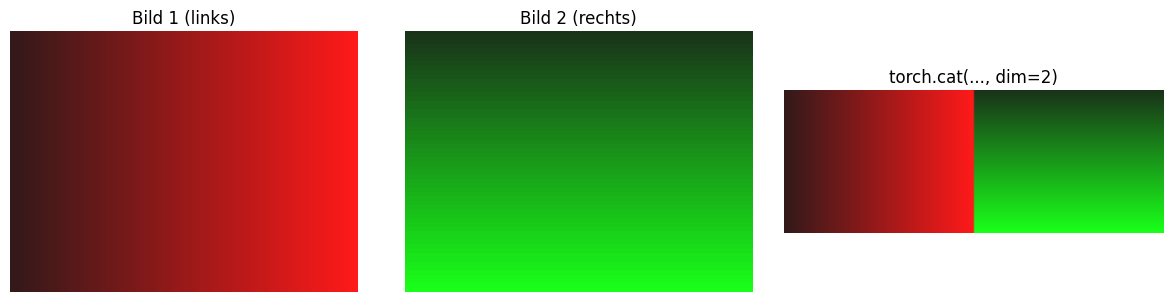

In [1]:
import torch
import matplotlib.pyplot as plt

# Zwei kleine RGB-Bilder als Tensoren im Format (C, H, W)
# C=3 (RGB), H=60, W=80
H, W = 60, 80
img_left = torch.zeros(3, H, W)
img_right = torch.zeros(3, H, W)

# Linkes Bild: rot mit Farbverlauf in x-Richtung
x = torch.linspace(0.2, 1.0, W).view(1, 1, W).repeat(1, H, 1)
img_left[0] = x[0]   # R
img_left[1] = 0.1    # G
img_left[2] = 0.1    # B

# Rechtes Bild: grün mit Farbverlauf in y-Richtung
y = torch.linspace(0.2, 1.0, H).view(1, H, 1).repeat(1, 1, W)
img_right[0] = 0.1   # R
img_right[1] = y[0]  # G
img_right[2] = 0.1   # B

# Horizontales Zusammenfügen: entlang der Breite W => dim=2
img_big = torch.cat([img_left, img_right], dim=2)

print('Form linkes Bild :', tuple(img_left.shape))
print('Form rechtes Bild:', tuple(img_right.shape))
print('Form großes Bild :', tuple(img_big.shape))

# Für matplotlib von (C, H, W) -> (H, W, C)
left_np = img_left.permute(1, 2, 0).numpy()
right_np = img_right.permute(1, 2, 0).numpy()
big_np = img_big.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(left_np)
axes[0].set_title('Bild 1 (links)')
axes[1].imshow(right_np)
axes[1].set_title('Bild 2 (rechts)')
axes[2].imshow(big_np)
axes[2].set_title('torch.cat(..., dim=2)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()